In [1]:
import os
import sys
from pathlib import Path

file_path = os.getcwd()
print(file_path)
project_root = Path(file_path).parent.parent.parent
sys.path.insert(0, str(project_root))
print(sys.path)

import numpy as np
import HydroArray as ha
from HydroArray.domain.process.crosssection import calculate_cross_section_area
from HydroArray.plotting.crosssection import cross_section_quick_plot
from HydroArray.utils.rounding import round_area

ha.use_hydro_style(style="hess", dpi=100)

e:\Projects\HydroArray\examples\basic\大断面的计算
['e:\\Projects\\HydroArray', 'd:\\miniconda3\\python313.zip', 'd:\\miniconda3\\DLLs', 'd:\\miniconda3\\Lib', 'd:\\miniconda3', '', 'd:\\miniconda3\\Lib\\site-packages', 'e:\\lavachen\\school-project\\src\\researchscaffold', 'd:\\miniconda3\\Lib\\site-packages\\win32', 'd:\\miniconda3\\Lib\\site-packages\\win32\\lib', 'd:\\miniconda3\\Lib\\site-packages\\Pythonwin']


In [2]:
x_data = [
    6.0, 16.0, 24.0, 57.0, 102, 149, 192, 253, 299, 371, 487, 590, 690, 790, 870,
    890, 930, 990, 1050, 1110, 1170, 1190, 1210, 1230, 1271, 1288, 1313, 1315, 1318, 1319
]
z_data = [
    22.06, 19.93, 17.66, 17.23, 17.38, 14.69, 12.42, 11.45, 11.35, 10.85, 10.45, 8.35, 4.85, 3.05, 0.95,
    1.55, 1.35, 2.05, 2.35, 3.25, 3.75, 2.85, 7.55, 3.25, 12.38, 13.58, 15.11, 18.21, 20.21, 22.06
]

water_levels = np.round(np.arange(0.95, 21.75 + 0.2, 0.2), 2).tolist()
if 22.06 not in water_levels:
    water_levels.append(22.06)

In [3]:
print(f"{'Elevation(m)':<15} | {'Area(m2)':<15}")
print("-" * 35)

areas = calculate_cross_section_area(x_data, z_data, water_levels)
for i, area in enumerate(areas):
    wl = water_levels[i]
    area_rounded = round_area(area[1])
    # 根据数值大小格式化输出
    if area_rounded >= 100:
        area_str = f"{int(area_rounded)}"
    elif area_rounded >= 10:
        area_str = f"{area_rounded:.1f}"
    else:
        area_str = f"{area_rounded:.2f}"
    print(f"{wl:<15.2f} | {area_str:<15}")

Elevation(m)    | Area(m2)       
-----------------------------------
0.95            | 0.00           
1.15            | 1.43           
1.35            | 5.71           
1.55            | 18.6           
1.75            | 41.0           
1.95            | 68.5           
2.15            | 101            
2.35            | 143            
2.55            | 192            
2.75            | 245            
2.95            | 302            
3.15            | 365            
3.35            | 433            
3.55            | 510            
3.75            | 595            
3.95            | 686            
4.15            | 780            
4.35            | 876            
4.55            | 975            
4.75            | 1080           
4.95            | 1180           
5.15            | 1290           
5.35            | 1400           
5.55            | 1510           
5.75            | 1620           
5.95            | 1730           
6.15            | 1840           
6.35        

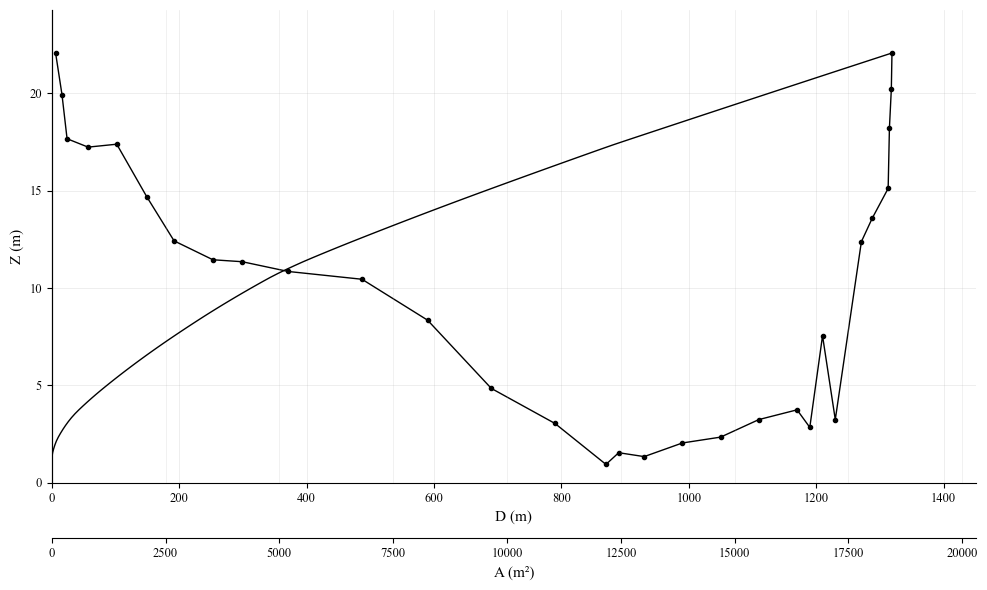

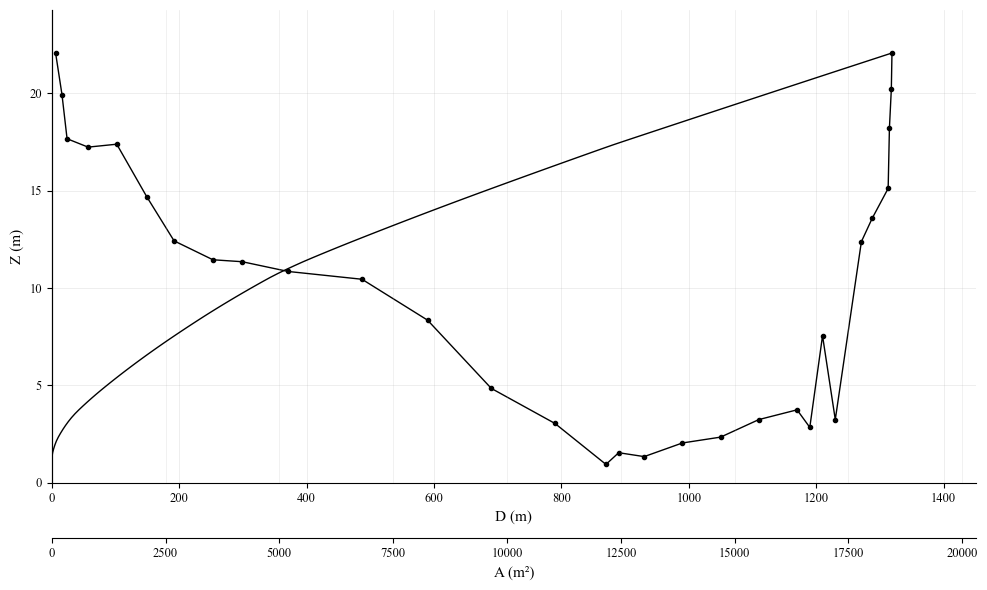

In [4]:
cross_section_quick_plot(
    x_data=x_data,
    z_data=z_data,
    results=areas,
    sample_levels=[5.0, 10.0, 15.0, 20.0],
    show=True,
    language="zh"
)